# Importación de librerías.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Inicio

Grupo:
* Ana Gónzales Núñez
* Javier Argenta Cañas
* Luis Sánchez Agulla
* Miguel Ciordia Isac

## Descripción del problema

Entrenamiento de una RNN basada en arquitectura SOM para poder clasificar un conjunto de datos propios de los países.


## Importación de datos

In [3]:
df = pd.read_csv("world_data.csv")

## Previsualización de los datos

Buscamos previsualizar los datos del CSV:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Observamos dentro del conjunto de datos una única variable categórica que representa el nombre de cada país usado dentro del dataset.

Observando la descripción básica del conjunto de datos dado, podemos referenciar que hay un conjunto de instancias que representan una inflación mínima inferior a 0 (negativa). Dada la naturaleza del dato, podemos concluir que a pesar de ser "atípico" en concepto, es posible dentro del mundo qu eexista dicho caso, pasando a ser conocido como "deflación."

In [10]:
valores_negativos = df[df['inflation'] < 0]
print(valores_negativos)

            country  child_mort  exports  health  imports  income  inflation  \
10          Bahamas        13.8     35.0    7.89     43.7   22900     -0.393   
43   Czech Republic         3.4     66.0    7.88     62.9   28300     -1.430   
73          Ireland         4.2    103.0    9.19     86.5   45700     -3.220   
77            Japan         3.2     15.0    9.49     13.6   35800     -1.900   
85           Latvia         7.8     53.7    6.68     55.1   18300     -0.812   
131      Seychelles        14.4     93.8    3.40    108.0   20400     -4.210   
133       Singapore         2.8    200.0    3.96    174.0   72100     -0.046   
135        Slovenia         3.2     64.3    9.41     62.9   28700     -0.987   

     life_expec  total_fer   gdpp  
10         73.8       1.86  28000  
43         77.5       1.51  19800  
73         80.4       2.05  48700  
77         82.8       1.39  44500  
85         73.1       1.36  11300  
131        73.4       2.17  10800  
133        82.7       1.15 

Dentro del conjunto de datos totales, podemos identificar hasta 8 países distintos que presentan un valor atípico dentro del concepto de inflación: Bahamas, Republica Checa, Irlanda, Japón, Letonia, Seychelles, Singapúr y Eslovenia. A pesar de presentar dichos valores, como se ha indicado previamente, se mantiene dichos valores dado que son plausibles.

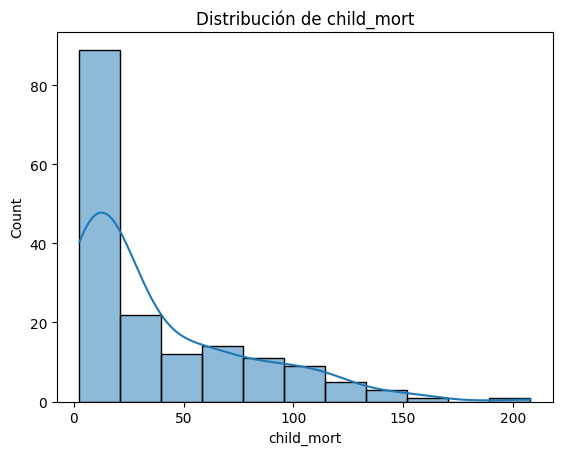

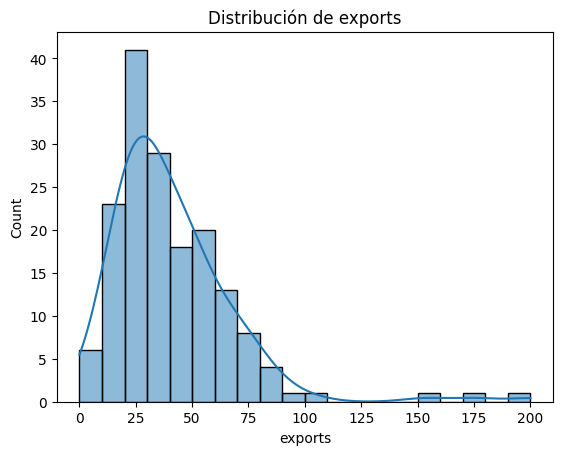

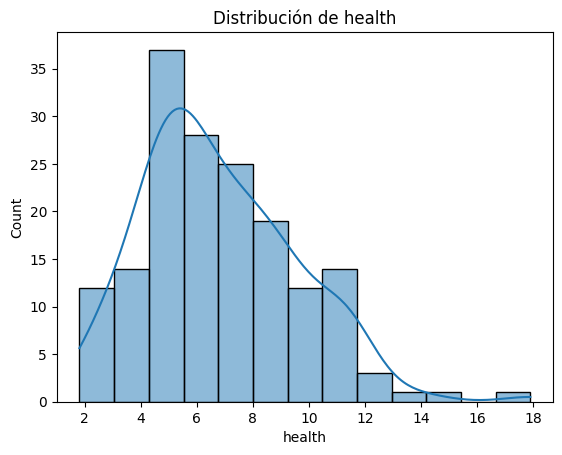

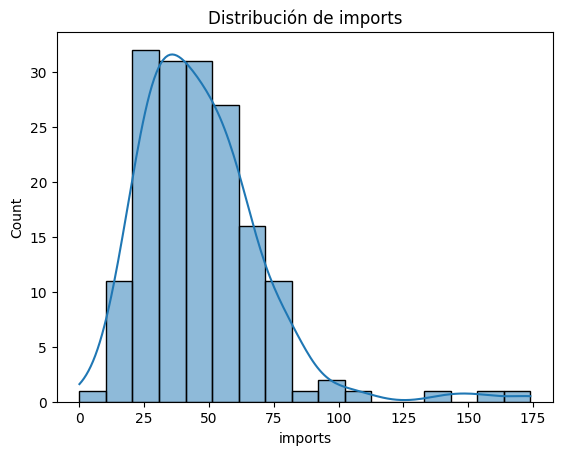

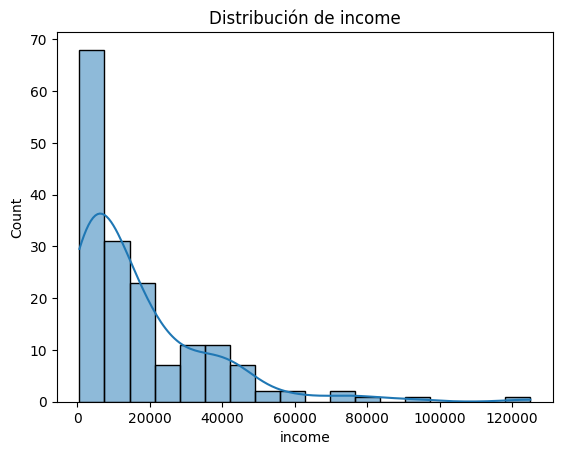

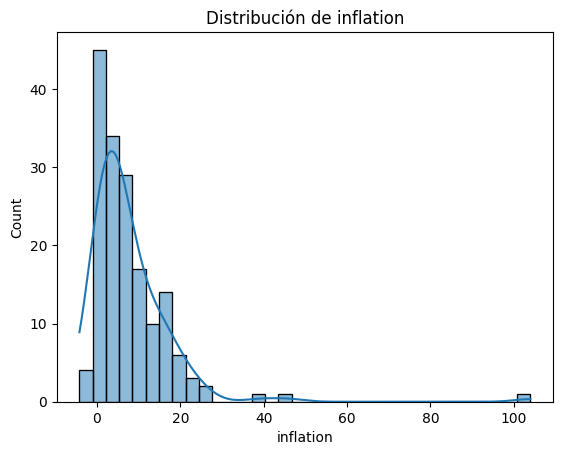

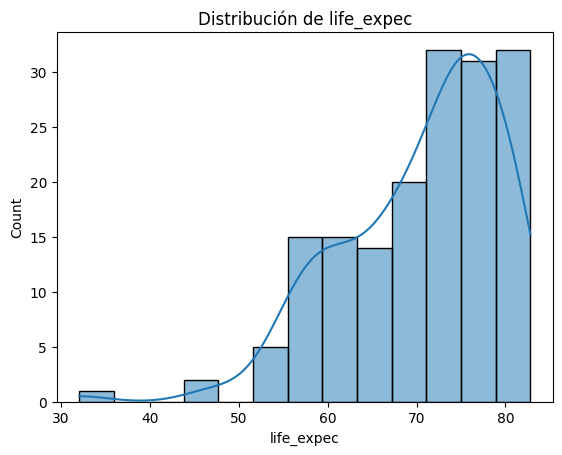

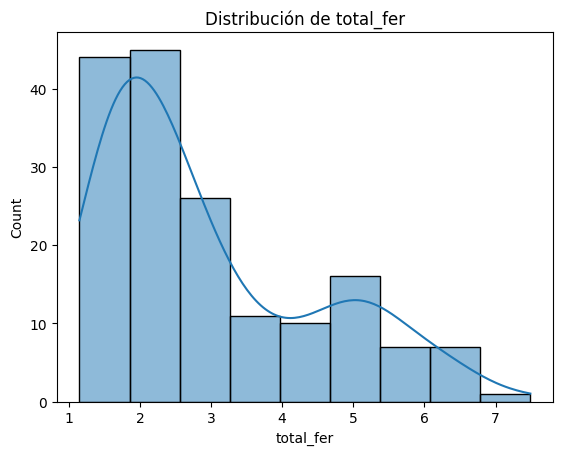

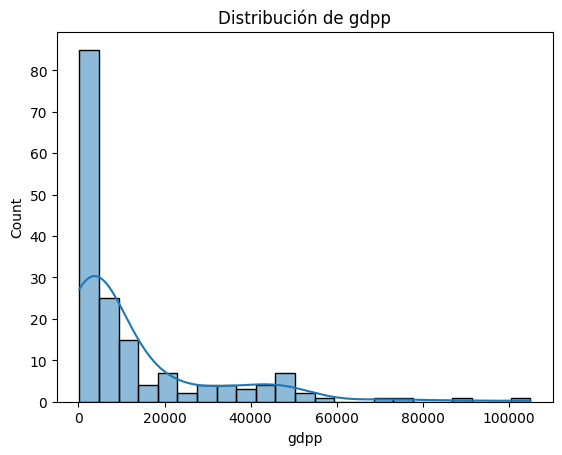

In [23]:
# Columnas de todo el dataframe menos la columna de 'country'
columnas = df.columns[1:]

for col in columnas:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

Visualizamos el conjunto de datos, para poder discernir la presencia de valores nulos a lo largo de todo el dataset.

In [8]:
null_values = df.isnull().sum()
print(null_values)

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Como podemos apreciar, el dataset no presenta ningún dato nulo a lo largo de todo el conjunto de instancias dadas, de manera que la limpieza de datos no hace falta que se ambiente en la sustitución de datos, inclusión de nuevos o reducción del tamaño del dataset.

Exploramos del conjunto de datos para poder destacar los outliers en cada una de las variables. Para poder hacerlo, vamos a calcular los quartiles Q1, Q3 y el rango IQR. Sacando dichas variables estadísticas y apoyandonos en ellas, buscamos saber cuantas instancias son consideradas atípicas.

In [22]:
df_sin_country = df.drop('country', axis = 1)

for col in df_sin_country:
  Q1 = df_sin_country[col].quantile(0.25)
  Q3 = df_sin_country[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df_sin_country[(df_sin_country[col] < lower_bound) | (df_sin_country[col] > upper_bound)]
  contador_outliers = len(outliers)
  print("Outliers en la columna: ", col, ". Cantidad de outliers en dicha columna: ", contador_outliers, "\n")

Outliers en la columna:  child_mort . Cantidad de outliers en dicha columna:  4 

Outliers en la columna:  exports . Cantidad de outliers en dicha columna:  5 

Outliers en la columna:  health . Cantidad de outliers en dicha columna:  2 

Outliers en la columna:  imports . Cantidad de outliers en dicha columna:  4 

Outliers en la columna:  income . Cantidad de outliers en dicha columna:  8 

Outliers en la columna:  inflation . Cantidad de outliers en dicha columna:  5 

Outliers en la columna:  life_expec . Cantidad de outliers en dicha columna:  3 

Outliers en la columna:  total_fer . Cantidad de outliers en dicha columna:  1 

Outliers en la columna:  gdpp . Cantidad de outliers en dicha columna:  25 



Dentro del dataset que se nos presenta, podemos estudiar las correlaciones propias de entre cada una de las variables, de forma que podamos posteriormente decidir cuales seleccionamos para poder realizar el entrenamiento de la Red Neuronal.

Dada la naturaleza de los datos, hay que tener en cuenta que las variables altamente correlacionadas pueden incurrir en datos redundantes, haciendo que se puedan seleccionar un conjunto concreto de atributos a raíz de dicho juicio.

Además, podemos sacar una tabla de correlaciones importantes entre variables para poder guiar el estudio de este aspecto del dataset.

<Axes: >

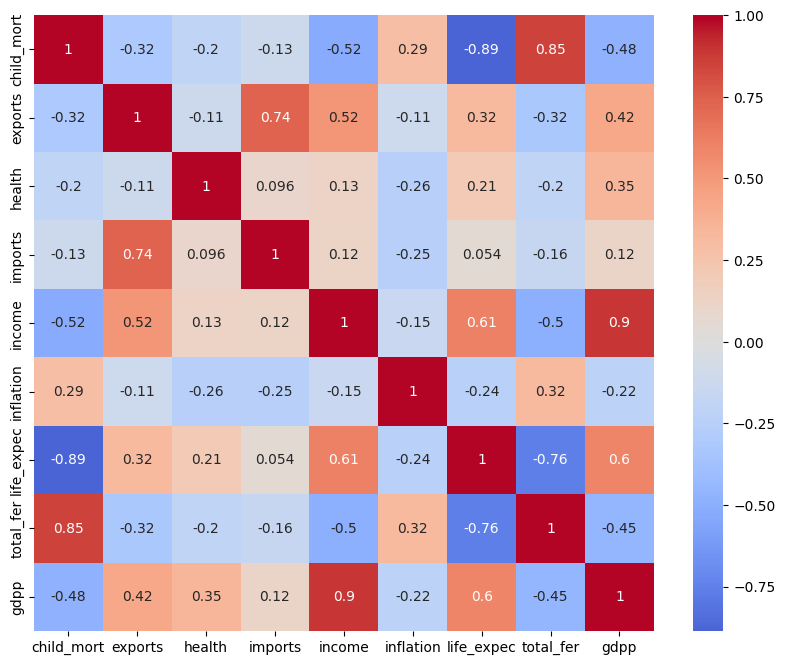

In [15]:
df_sin_country = df.drop('country', axis=1)

corr_matrix = df_sin_country.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    cbar=True
)